In [ ]:
# New version code: the ploidy can change (+1 or -1) based on previous ploidy. And this file only considered the ploidy effect.

# This file is used to compare the fitness of different strength
# of stablizing selection for ploidy changes (i.e., different sigma: 0.5, 1, 5 and 10) with different population size (here N =5, 
# 10, 20 and 100). All the simulations were run for 10 K generations.

# The raw data used for this file can be found in the following folder:
# E:\Prof. Azevedo\Simulation of Ciliate Evolution\20170228_Introduce Unstable Ploidy Copy No. 
# During Amitosis_Ploidy Change 1 based on previous ploidy\Data\Solely Ploidy Effect

# The figures plotted by this file can be found in the following folder:
# E:\Prof. Azevedo\Simulation of Ciliate Evolution\20170228_Introduce Unstable Ploidy Copy No. 
# During Amitosis_Ploidy Change 1 based on previous ploidy\Figures\Only Ploidy Effect

In [144]:
import numpy as np
import scipy.spatial as spa
import random
import pandas as pd 
from scipy.linalg import hadamard
import itertools as it 
import scipy.stats as stat
import scipy.integrate as integrate
import math
import argparse
import os

In [145]:
generation_list = []

for i in range(1001):
    generation_list.append(10*i)
    
print(len(generation_list))

1001


In [146]:
os.chdir(r"E:\Prof. Azevedo\Simulation of Ciliate Evolution\20170228_Introduce Unstable Ploidy Copy No. During Amitosis_Ploidy Change 1 based on previous ploidy\Data\Solely Ploidy Effect")

In [147]:
s05_file = ['P_N_S05_Fitness_WF_5_CH_Ploidy_10K.csv', 'P_N_S05_Fitness_WF_10_CH_Ploidy_10K.csv', 'P_N_S05_Fitness_WF_20_CH_Ploidy_10K.csv', \
             'P_N_S05_Fitness_WF_50_CH_Ploidy_10K.csv','P_N_S05_Fitness_WF_100_CH_Ploidy_10K.csv'  ]


s05_mfit = []
s05_log_mfit = []
s05_mlog_fit = []
s05_mPloidy = []
s05_varPloidy = []

g_s05_mfit = []
g_s05_log_mfit = []
g_s05_mlog_fit = []


for i in s05_file:
    s05 = pd.read_csv(i,dtype=str)
    
    mfit = []
    log_mfit = []
    mlog_fit = []
    mPloidy = []
    varPloidy = []
    
    g_mfit = []
    g_log_mfit = []
    g_mlog_fit = []    
    
    mfit.extend(list(pd.Series(s05.meanFit,dtype=float)))
    log_mfit.extend(list(pd.Series(s05.log_meanFit,dtype=float)))
    mlog_fit.extend(list(pd.Series(s05.mean_logFit, dtype=float)))
    mPloidy.extend(list(pd.Series(s05.meanPloidy, dtype=float)))
    varPloidy.extend(list(pd.Series(s05.VarPloidy, dtype=float)))
    
    
    g_mfit.extend(list(pd.Series(s05.meanFit_Germ,dtype=float)))
    g_log_mfit.extend(list(pd.Series(s05.log_meanFit_Germ,dtype=float)))
    g_mlog_fit.extend(list(pd.Series(s05.mean_logFit_Germ, dtype=float)))    
                
    s05_mfit.append(mfit)
    s05_log_mfit.append(log_mfit)
    s05_mlog_fit.append(mlog_fit)
    
    s05_mPloidy.append(mPloidy)
    s05_varPloidy.append(varPloidy)

    
    g_s05_mfit.append(g_mfit)
    g_s05_log_mfit.append(g_log_mfit)
    g_s05_mlog_fit.append(g_mlog_fit)

In [148]:
s1_file = ['P_N_S1_Fitness_WF_5_CH_Ploidy_10K.csv', 'P_N_S1_Fitness_WF_10_CH_Ploidy_10K.csv', 'P_N_S1_Fitness_WF_20_CH_Ploidy_10K.csv', \
             'P_N_S1_Fitness_WF_50_CH_Ploidy_10K.csv', 'P_N_S1_Fitness_WF_100_CH_Ploidy_10K.csv']


s1_mfit = []
s1_log_mfit = []
s1_mlog_fit = []

s1_mPloidy = []
s1_varPloidy = []

g_s1_mfit = []
g_s1_log_mfit = []
g_s1_mlog_fit = []


for i in s1_file:
    s1 = pd.read_csv(i,dtype=str)
    
    mfit = []
    log_mfit = []
    mlog_fit = []
    
    mPloidy = []
    varPloidy = []    
    
    g_mfit = []
    g_log_mfit = []
    g_mlog_fit = []    
    
    mfit.extend(list(pd.Series(s1.meanFit,dtype=float)))
    log_mfit.extend(list(pd.Series(s1.log_meanFit,dtype=float)))
    mlog_fit.extend(list(pd.Series(s1.mean_logFit, dtype=float)))
    
    mPloidy.extend(list(pd.Series(s1.meanPloidy, dtype=float)))
    varPloidy.extend(list(pd.Series(s1.VarPloidy, dtype=float)))    
    
    g_mfit.extend(list(pd.Series(s1.meanFit_Germ,dtype=float)))
    g_log_mfit.extend(list(pd.Series(s1.log_meanFit_Germ,dtype=float)))
    g_mlog_fit.extend(list(pd.Series(s1.mean_logFit_Germ, dtype=float)))    
                
    s1_mfit.append(mfit)
    s1_log_mfit.append(log_mfit)
    s1_mlog_fit.append(mlog_fit)
    
    s1_mPloidy.append(mPloidy)
    s1_varPloidy.append(varPloidy)

    
    g_s1_mfit.append(g_mfit)
    g_s1_log_mfit.append(g_log_mfit)
    g_s1_mlog_fit.append(g_mlog_fit)


In [149]:
s5_file = ['P_N_S5_Fitness_WF_5_CH_Ploidy_10K.csv', 'P_N_S5_Fitness_WF_10_CH_Ploidy_10K.csv', 'P_N_S5_Fitness_WF_20_CH_Ploidy_10K.csv', \
             'P_N_S5_Fitness_WF_50_CH_Ploidy_10K.csv', 'P_N_S5_Fitness_WF_100_CH_Ploidy_10K.csv']


s5_mfit = []
s5_log_mfit = []
s5_mlog_fit = []

s5_mPloidy = []
s5_varPloidy = []

g_s5_mfit = []
g_s5_log_mfit = []
g_s5_mlog_fit = []


for i in s5_file:
    s5 = pd.read_csv(i,dtype=str)
    
    mfit = []
    log_mfit = []
    mlog_fit = []
    
    mPloidy = []
    varPloidy = []
    
    g_mfit = []
    g_log_mfit = []
    g_mlog_fit = []    
    
    mfit.extend(list(pd.Series(s5.meanFit,dtype=float)))
    log_mfit.extend(list(pd.Series(s5.log_meanFit,dtype=float)))
    mlog_fit.extend(list(pd.Series(s5.mean_logFit, dtype=float)))
    
    mPloidy.extend(list(pd.Series(s5.meanPloidy, dtype=float)))
    varPloidy.extend(list(pd.Series(s5.VarPloidy, dtype=float)))       
    
    g_mfit.extend(list(pd.Series(s5.meanFit_Germ,dtype=float)))
    g_log_mfit.extend(list(pd.Series(s5.log_meanFit_Germ,dtype=float)))
    g_mlog_fit.extend(list(pd.Series(s5.mean_logFit_Germ, dtype=float)))    
                
    s5_mfit.append(mfit)
    s5_log_mfit.append(log_mfit)
    s5_mlog_fit.append(mlog_fit)

    s5_mPloidy.append(mPloidy)
    s5_varPloidy.append(varPloidy)

    
    g_s5_mfit.append(g_mfit)
    g_s5_log_mfit.append(g_log_mfit)
    g_s5_mlog_fit.append(g_mlog_fit)


In [150]:
s10_file = ['P_N_S10_Fitness_WF_5_CH_Ploidy_10K.csv', 'P_N_S10_Fitness_WF_10_CH_Ploidy_10K.csv', 'P_N_S10_Fitness_WF_20_CH_Ploidy_10K.csv', \
             'P_N_S10_Fitness_WF_50_CH_Ploidy_10K.csv', 'P_N_S10_Fitness_WF_100_CH_Ploidy_10K.csv']


s10_mfit = []
s10_log_mfit = []
s10_mlog_fit = []

s10_mPloidy = []
s10_varPloidy = []

g_s10_mfit = []
g_s10_log_mfit = []
g_s10_mlog_fit = []


for i in s10_file:
    s10 = pd.read_csv(i,dtype=str)
    
    mfit = []
    log_mfit = []
    mlog_fit = []
    
    mPloidy = []
    varPloidy = []
    
    g_mfit = []
    g_log_mfit = []
    g_mlog_fit = []    
    
    mfit.extend(list(pd.Series(s10.meanFit,dtype=float)))
    log_mfit.extend(list(pd.Series(s10.log_meanFit,dtype=float)))
    mlog_fit.extend(list(pd.Series(s10.mean_logFit, dtype=float)))
    
    mPloidy.extend(list(pd.Series(s10.meanPloidy, dtype=float)))
    varPloidy.extend(list(pd.Series(s10.VarPloidy, dtype=float)))      
    
    g_mfit.extend(list(pd.Series(s10.meanFit_Germ,dtype=float)))
    g_log_mfit.extend(list(pd.Series(s10.log_meanFit_Germ,dtype=float)))
    g_mlog_fit.extend(list(pd.Series(s10.mean_logFit_Germ, dtype=float)))    
                
    s10_mfit.append(mfit)
    s10_log_mfit.append(log_mfit)
    s10_mlog_fit.append(mlog_fit)

    s10_mPloidy.append(mPloidy)
    s10_varPloidy.append(varPloidy)
    
    g_s10_mfit.append(g_mfit)
    g_s10_log_mfit.append(g_log_mfit)
    g_s10_mlog_fit.append(g_mlog_fit)


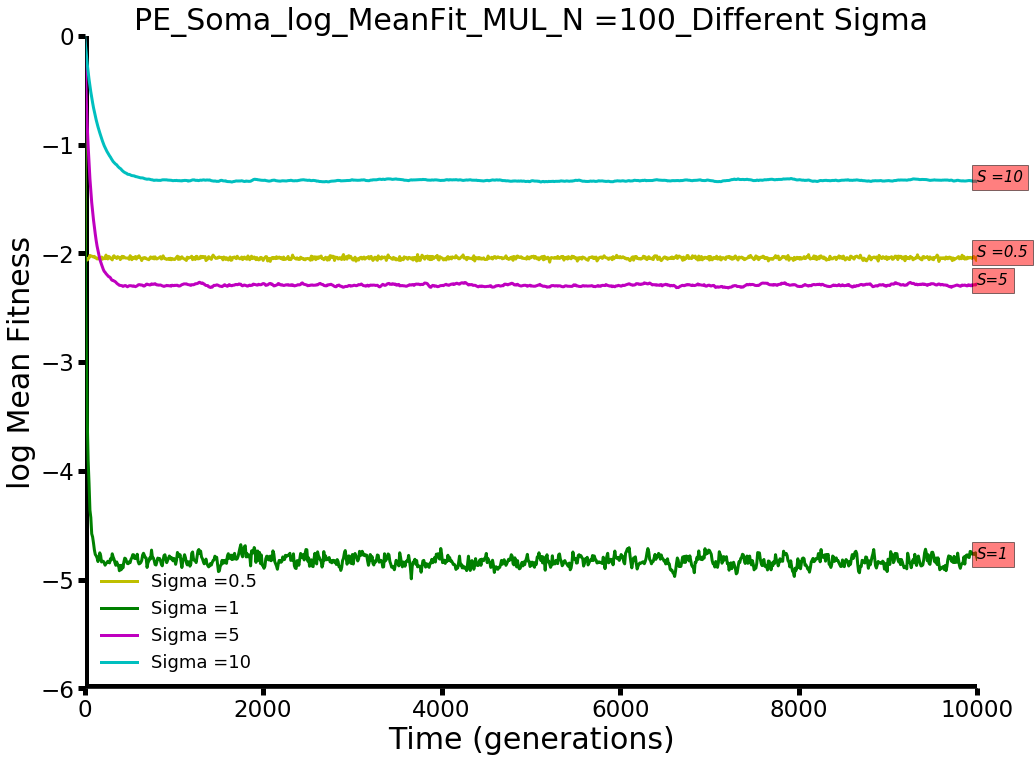

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

plt.figure(figsize=(16,12))

t = generation_list
# a = amito_log_mfit[4]
# b = mito_log_mfit[4]
c = s05_log_mfit[4]
d = s1_log_mfit[4]
e = s5_log_mfit[4]
f = s10_log_mfit[4]


plt.title('PE_Soma_log_MeanFit_MUL_N =100_Different Sigma', fontsize =30)
plt.xlabel('Time (generations)', fontsize =30)
plt.ylabel('log Mean Fitness', fontsize =30)
# plt.legend(['N =1', 'N =10', 'N =100', 'N =1000' ])
plt.rcParams.update({'font.size': 30})


# plt.show()
ax = plt.subplot(111)
ax.axhline(y=-6,linewidth=8, color ='black')       
ax.axvline(linewidth=8, color = 'black')        

# plt.plot(t,a,'r', label = 'Amito', ls = 'solid',linewidth=3.0) # plotting t,a separately 
# plt.plot(t,b,'b', label = 'Mito', ls= 'solid', linewidth=3.0) # plotting t,b separately 
plt.plot(t,c,'y', label = 'Sigma =0.5', ls = 'solid', linewidth=3.0) # plotting t,c separately 
plt.plot(t,d,'g', label = 'Sigma =1',ls = 'solid', linewidth=3.0)
plt.plot(t,e,'m', label = 'Sigma =5', ls = 'solid', linewidth=3.0)
plt.plot(t,f,'c', label = 'Sigma =10',ls= 'solid', linewidth=3.0)

plt.tick_params(axis='both', labelsize=23)

# ax.text(t[-1], a[-1], 'Amito', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

# ax.text(t[-1], b[-1], 'Mito', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

ax.text(t[-1], c[-1], 'S =0.5', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

ax.text(t[-1], d[-1], 'S=1', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

ax.text(t[-1], e[-1], 'S=5', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5},fontsize =15 )

ax.text(t[-1], f[-1], 'S =10', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)


plt.xlim(0, 10001)


# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


ax.xaxis.set_tick_params(width=5, length =7)
ax.yaxis.set_tick_params(width=5, length =7)

# plt.legend(loc='upper right', frameon=False)
plt.legend(loc='lower left', frameon=False, prop={'size':18})

plt.ylim(-6,0)
# plt.savefig('1', dpi=300, bbox_inches='tight')

plt.show()

1 44.999824
2 45.001216


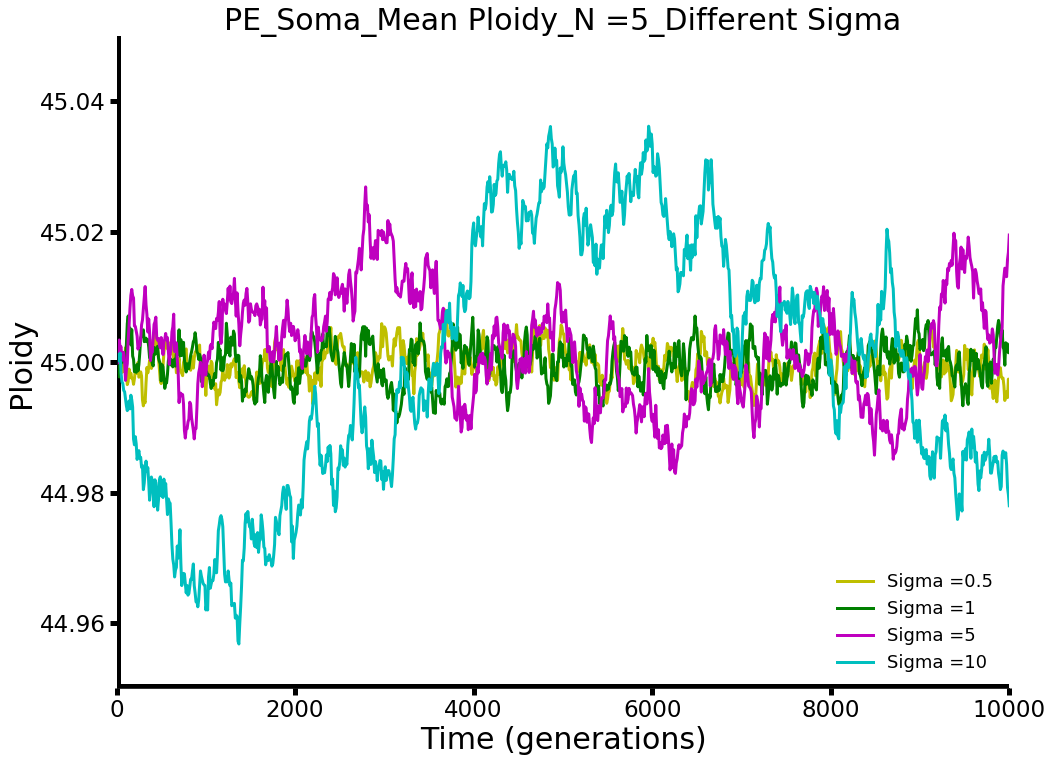

In [90]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

plt.figure(figsize=(16,12))

t = generation_list
# a = amito_log_mfit[4]
# b = mito_log_mfit[4]
c = s05_mPloidy[0]
d = s1_mPloidy[0]
e = s5_mPloidy[0]
f = s10_mPloidy[0]

print '1',e[1]
print '2', f[1]

plt.title('PE_Soma_Mean Ploidy_N =5_Different Sigma', fontsize =30)
plt.xlabel('Time (generations)', fontsize =30)
plt.ylabel('Ploidy', fontsize =30)
# plt.legend(['N =1', 'N =10', 'N =100', 'N =1000' ])
plt.rcParams.update({'font.size': 30})


# plt.show()
ax = plt.subplot(111)
ax.axhline(y=44.95,linewidth=8, color ='black')       
ax.axvline(linewidth=8, color = 'black')        

# plt.plot(t,a,'r', label = 'Amito', ls = 'solid',linewidth=3.0) # plotting t,a separately 
# plt.plot(t,b,'b', label = 'Mito', ls= 'solid', linewidth=3.0) # plotting t,b separately 
plt.plot(t,c,'y', label = 'Sigma =0.5', ls = 'solid', linewidth=3.0) # plotting t,c separately 
plt.plot(t,d,'g', label = 'Sigma =1',ls = 'solid', linewidth=3.0)
plt.plot(t,e,'m', label = 'Sigma =5', ls = 'solid', linewidth=3.0)
plt.plot(t,f,'c', label = 'Sigma =10',ls= 'solid', linewidth=3.0)

plt.tick_params(axis='both', labelsize=23)

# ax.text(t[-1], a[-1], 'Amito', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

# ax.text(t[-1], b[-1], 'Mito', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

# ax.text(t[-1], c[-1], 'S =0.5', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

# ax.text(t[-1], d[-1], 'S=1', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

# ax.text(t[-1], e[-1], 'S=5', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5},fontsize =15 )

# ax.text(t[-1], f[-1], 'S =10', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)


plt.xlim(0, 10001)


# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


ax.xaxis.set_tick_params(width=5, length =7)
ax.yaxis.set_tick_params(width=5, length =7)

# plt.legend(loc='upper right', frameon=False)
plt.legend(loc='lower right', frameon=False, prop={'size':18})

plt.ylim(44.95,45.050)
# plt.savefig('1', dpi=300, bbox_inches='tight')

plt.show()

1 0.16533155148
2 0.17533370228


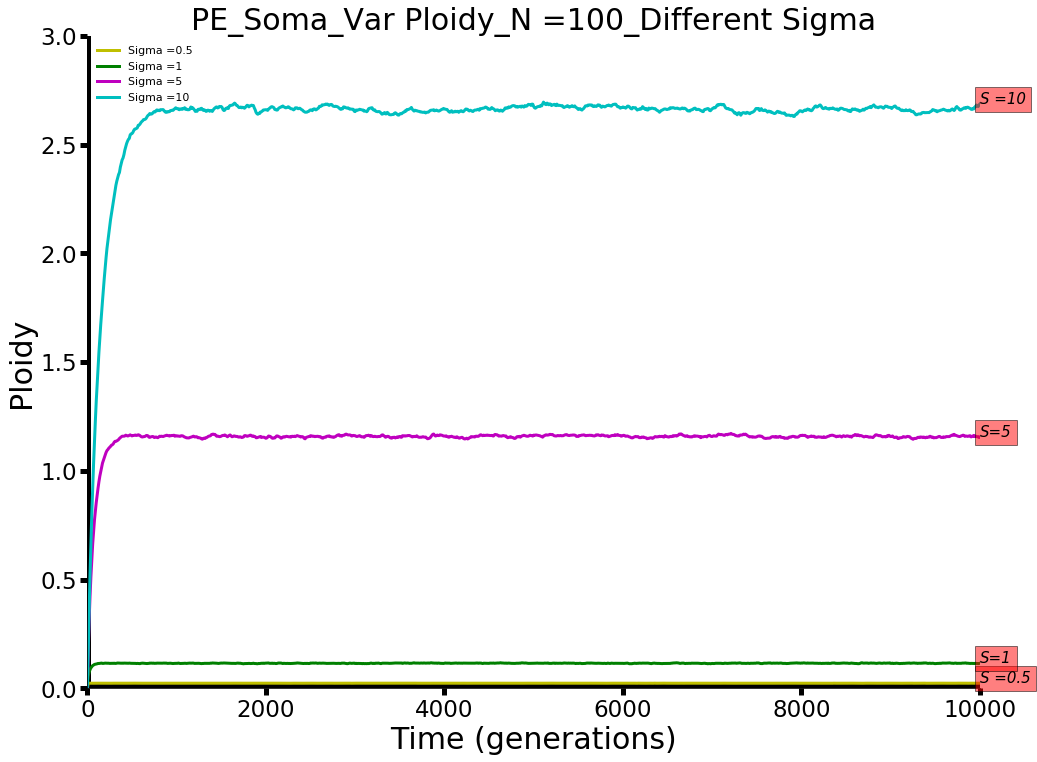

In [110]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

plt.figure(figsize=(16,12))

t = generation_list
# a = amito_log_mfit[4]
# b = mito_log_mfit[4]
c = s05_varPloidy[4]
d = s1_varPloidy[4]
e = s5_varPloidy[4]
f = s10_varPloidy[4]

print '1',e[1]
print '2', f[1]

plt.title('PE_Soma_Var Ploidy_N =100_Different Sigma', fontsize =30)
plt.xlabel('Time (generations)', fontsize =30)
plt.ylabel('Ploidy', fontsize =30)
# plt.legend(['N =1', 'N =10', 'N =100', 'N =1000' ])
plt.rcParams.update({'font.size': 30})


# plt.show()
ax = plt.subplot(111)
ax.axhline(y=0,linewidth=8, color ='black')       
ax.axvline(linewidth=8, color = 'black')        

# plt.plot(t,a,'r', label = 'Amito', ls = 'solid',linewidth=3.0) # plotting t,a separately 
# plt.plot(t,b,'b', label = 'Mito', ls= 'solid', linewidth=3.0) # plotting t,b separately 
plt.plot(t,c,'y', label = 'Sigma =0.5', ls = 'solid', linewidth=3.0) # plotting t,c separately 
plt.plot(t,d,'g', label = 'Sigma =1',ls = 'solid', linewidth=3.0)
plt.plot(t,e,'m', label = 'Sigma =5', ls = 'solid', linewidth=3.0)
plt.plot(t,f,'c', label = 'Sigma =10',ls= 'solid', linewidth=3.0)

plt.tick_params(axis='both', labelsize=23)

# ax.text(t[-1], a[-1], 'Amito', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

# ax.text(t[-1], b[-1], 'Mito', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

ax.text(t[-1], c[-1], 'S =0.5', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

ax.text(t[-1], d[-1], 'S=1', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

ax.text(t[-1], e[-1], 'S=5', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5},fontsize =15 )

ax.text(t[-1], f[-1], 'S =10', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)


plt.xlim(0, 10001)


# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


ax.xaxis.set_tick_params(width=5, length =7)
ax.yaxis.set_tick_params(width=5, length =7)

# plt.legend(loc='upper right', frameon=False)
plt.legend(loc='upper left', frameon=False, prop={'size':11})

plt.ylim(0,3)
# plt.savefig('1', dpi=300, bbox_inches='tight')

plt.show()

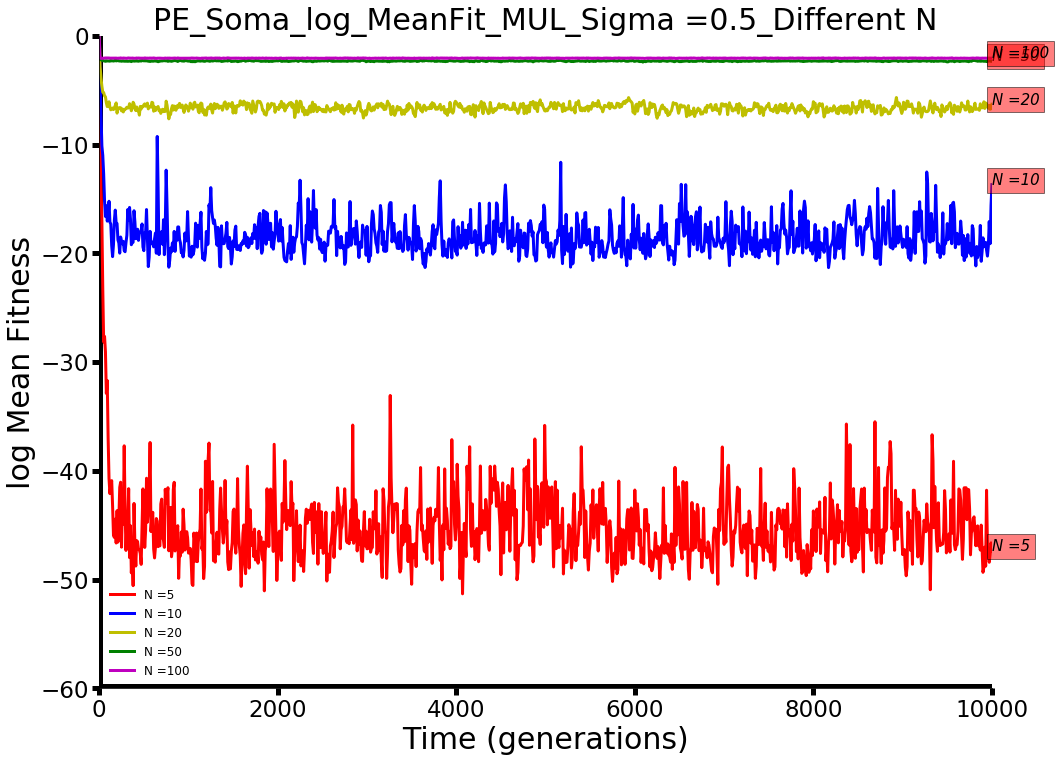

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

plt.figure(figsize=(16,12))

t = generation_list
a = s05_log_mfit[0]
b = s05_log_mfit[1]
c = s05_log_mfit[2]
d = s05_log_mfit[3]
e = s05_log_mfit[4]



plt.title('PE_Soma_log_MeanFit_MUL_Sigma =0.5_Different N', fontsize =30)
plt.xlabel('Time (generations)', fontsize =30)
plt.ylabel('log Mean Fitness', fontsize =30)
# plt.legend(['N =1', 'N =10', 'N =100', 'N =1000' ])
plt.rcParams.update({'font.size': 30})


# plt.show()
ax = plt.subplot(111)
ax.axhline(y=-60,linewidth=8, color ='black')       
ax.axvline(linewidth=8, color = 'black')        

plt.plot(t,a,'r', label = 'N =5', ls = 'solid',linewidth=3.0) # plotting t,a separately 
plt.plot(t,b,'b', label = 'N =10', ls= 'solid', linewidth=3.0) # plotting t,b separately 
plt.plot(t,c,'y', label = 'N =20', ls = 'solid', linewidth=3.0) # plotting t,c separately 
plt.plot(t,d,'g', label = 'N =50',ls = 'solid', linewidth=3.0)
plt.plot(t,e,'m', label = 'N =100', ls = 'solid', linewidth=3.0)
# plt.plot(t,f,'c', label = 'Sigma =10',ls= 'solid', linewidth=3.0)

plt.tick_params(axis='both', labelsize=23)

ax.text(t[-1], a[-1], 'N =5', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

ax.text(t[-1], b[-1], 'N =10', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

ax.text(t[-1], c[-1], 'N =20', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

ax.text(t[-1], d[-1], 'N =50', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

ax.text(t[-1], e[-1], 'N =100', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5},fontsize =15 )

# ax.text(t[-1], f[-1], 'S =10', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)


plt.xlim(0, 10001)


# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


ax.xaxis.set_tick_params(width=5, length =7)
ax.yaxis.set_tick_params(width=5, length =7)

# plt.legend(loc='upper right', frameon=False)
plt.legend(loc='lower left', frameon=False, prop={'size':12})

plt.ylim(-60,0)
# plt.savefig('1', dpi=300, bbox_inches='tight')

plt.show()

1 44.9995648
2 44.999772


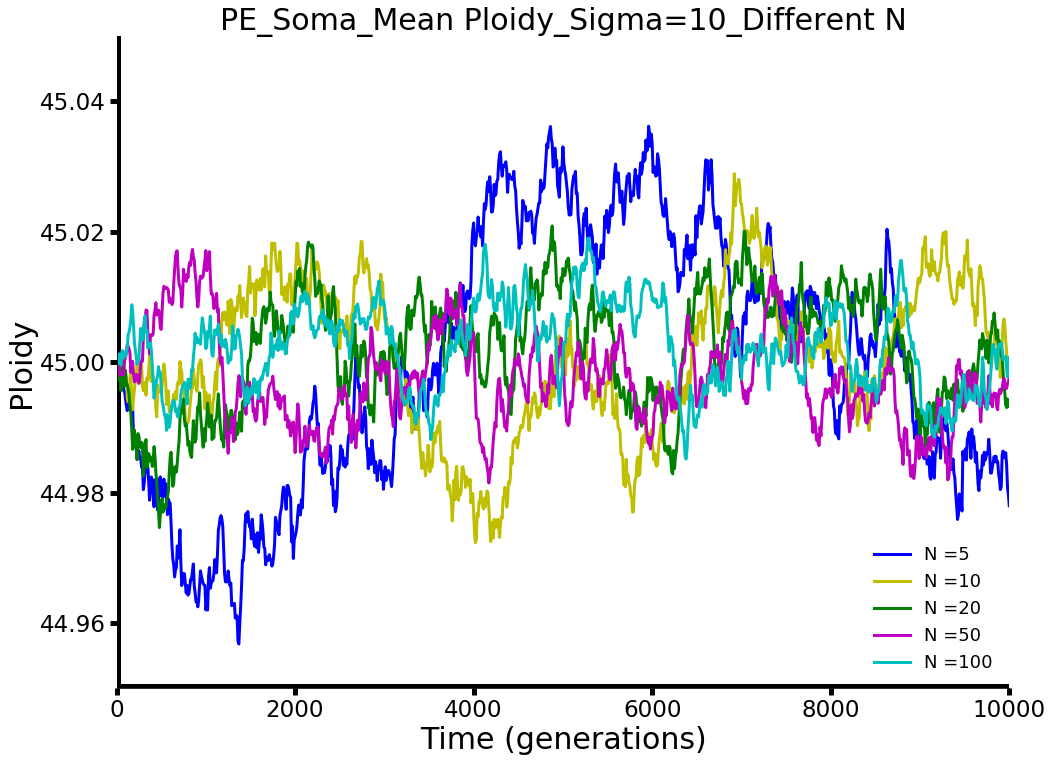

In [123]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

plt.figure(figsize=(16,12))

t = generation_list
# a = amito_log_mfit[4]
b = s10_mPloidy[0]
c = s10_mPloidy[1]
d = s10_mPloidy[2]
e = s10_mPloidy[3]
f = s10_mPloidy[4]


print '1',e[1]
print '2', f[1]

plt.title('PE_Soma_Mean Ploidy_Sigma=10_Different N', fontsize =30)
plt.xlabel('Time (generations)', fontsize =30)
plt.ylabel('Ploidy', fontsize =30)
# plt.legend(['N =1', 'N =10', 'N =100', 'N =1000' ])
plt.rcParams.update({'font.size': 30})


# plt.show()
ax = plt.subplot(111)
ax.axhline(y=44.95,linewidth=8, color ='black')       
ax.axvline(linewidth=8, color = 'black')        

# plt.plot(t,a,'r', label = 'Amito', ls = 'solid',linewidth=3.0) # plotting t,a separately 
plt.plot(t,b,'b', label = 'N =5', ls= 'solid', linewidth=3.0) # plotting t,b separately 
plt.plot(t,c,'y', label = 'N =10', ls = 'solid', linewidth=3.0) # plotting t,c separately 
plt.plot(t,d,'g', label = 'N =20',ls = 'solid', linewidth=3.0)
plt.plot(t,e,'m', label = 'N =50', ls = 'solid', linewidth=3.0)
plt.plot(t,f,'c', label = 'N =100',ls= 'solid', linewidth=3.0)

plt.tick_params(axis='both', labelsize=23)

# ax.text(t[-1], a[-1], 'Amito', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

# ax.text(t[-1], b[-1], 'Mito', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

# ax.text(t[-1], c[-1], 'S =0.5', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

# ax.text(t[-1], d[-1], 'S=1', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

# ax.text(t[-1], e[-1], 'S=5', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5},fontsize =15 )

# ax.text(t[-1], f[-1], 'S =10', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)


plt.xlim(0, 10001)


# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


ax.xaxis.set_tick_params(width=5, length =7)
ax.yaxis.set_tick_params(width=5, length =7)

# plt.legend(loc='upper right', frameon=False)
plt.legend(loc='lower right', frameon=False, prop={'size':18})

plt.ylim(44.95,45.050)
# plt.savefig('1', dpi=300, bbox_inches='tight')

plt.show()

1 0.02425104472
2 0.02349550586


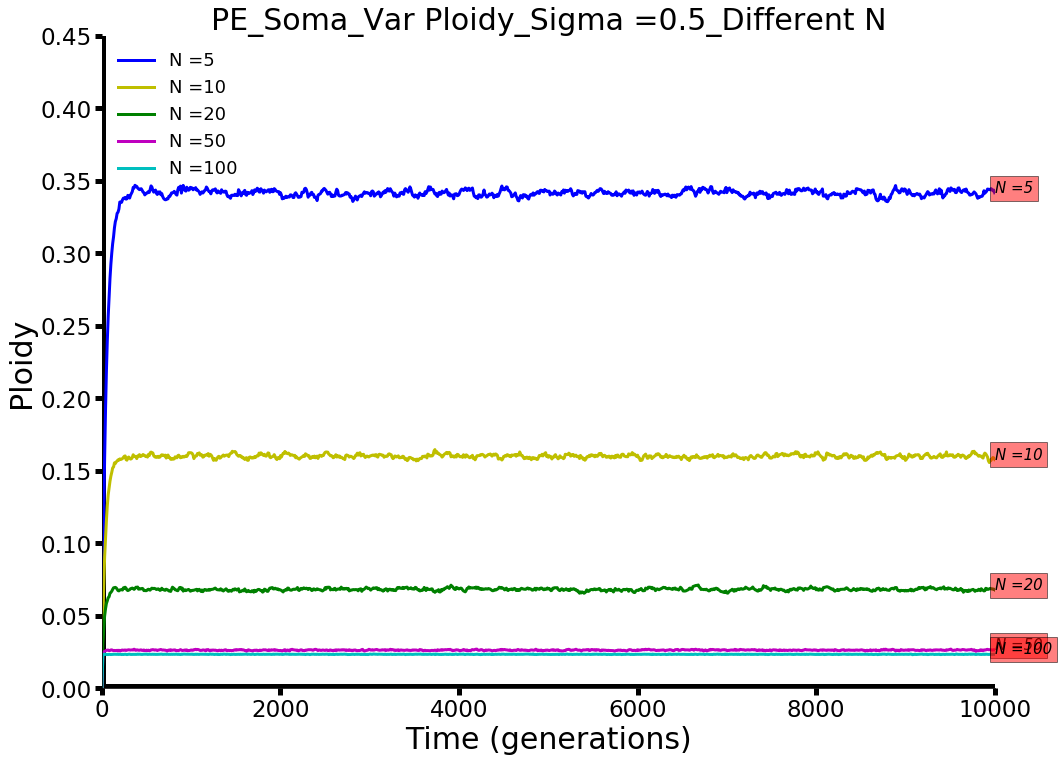

In [163]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

plt.figure(figsize=(16,12))

t = generation_list
# a = amito_log_mfit[4]
b = s05_varPloidy[0]
c = s05_varPloidy[1]
d = s05_varPloidy[2]
e = s05_varPloidy[3]
f = s05_varPloidy[4]

print '1',e[1]
print '2', f[1]

plt.title('PE_Soma_Var Ploidy_Sigma =0.5_Different N', fontsize =30)
plt.xlabel('Time (generations)', fontsize =30)
plt.ylabel('Ploidy', fontsize =30)
# plt.legend(['N =1', 'N =10', 'N =100', 'N =1000' ])
plt.rcParams.update({'font.size': 30})


# plt.show()
ax = plt.subplot(111)
ax.axhline(y=0,linewidth=8, color ='black')       
ax.axvline(linewidth=8, color = 'black')        

# plt.plot(t,a,'r', label = 'Amito', ls = 'solid',linewidth=3.0) # plotting t,a separately 
plt.plot(t,b,'b', label = 'N =5', ls= 'solid', linewidth=3.0) # plotting t,b separately 
plt.plot(t,c,'y', label = 'N =10', ls = 'solid', linewidth=3.0) # plotting t,c separately 
plt.plot(t,d,'g', label = 'N =20',ls = 'solid', linewidth=3.0)
plt.plot(t,e,'m', label = 'N =50', ls = 'solid', linewidth=3.0)
plt.plot(t,f,'c', label = 'N =100',ls= 'solid', linewidth=3.0)

plt.tick_params(axis='both', labelsize=23)

# ax.text(t[-1], a[-1], 'Amito', style='italic',
#         bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

ax.text(t[-1], b[-1], 'N =5', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

ax.text(t[-1], c[-1], 'N =10', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

ax.text(t[-1], d[-1], 'N =20', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)

ax.text(t[-1], e[-1], 'N =50', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5},fontsize =15 )

ax.text(t[-1], f[-1], 'N =100', style='italic',
        bbox={'facecolor':'red', 'alpha':0.5, 'pad':5}, fontsize =15)


plt.xlim(0, 10001)


# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


ax.xaxis.set_tick_params(width=5, length =7)
ax.yaxis.set_tick_params(width=5, length =7)

# plt.legend(loc='upper right', frameon=False)
plt.legend(loc='upper left', frameon=False, prop={'size':18})

plt.ylim(0,0.45)
# plt.savefig('1', dpi=300, bbox_inches='tight')

plt.show()

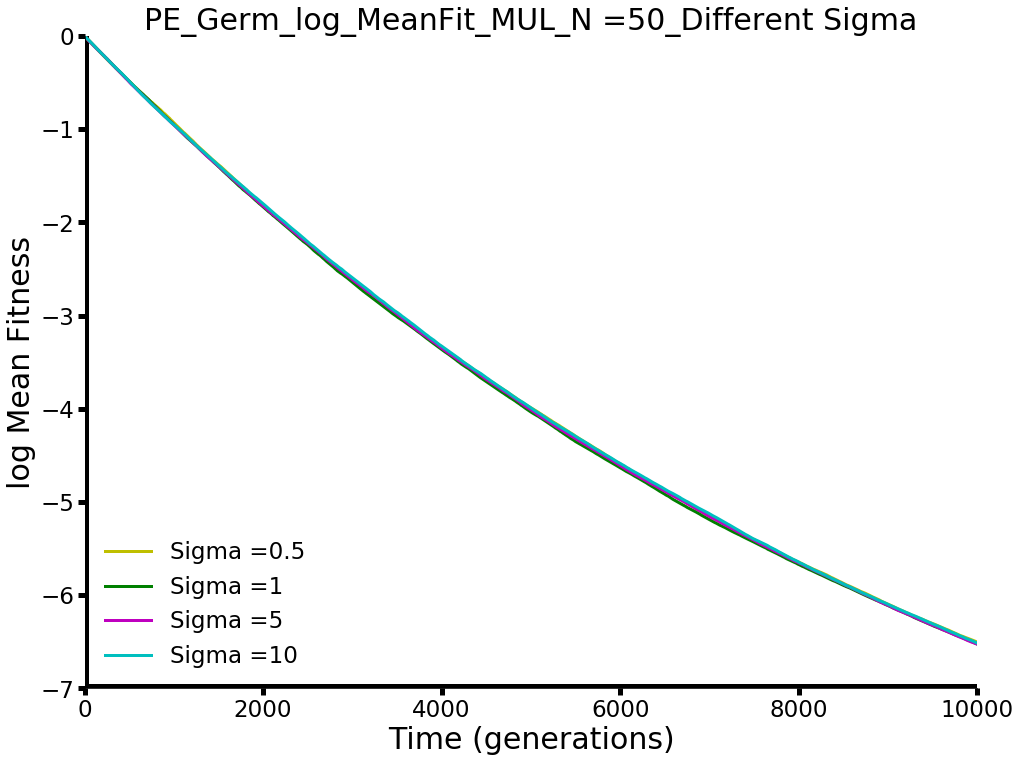

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

plt.figure(figsize=(16,12))

t = generation_list
# a = g_amito_log_mfit[4]
# b = g_mito_log_mfit[4]
c = g_s05_log_mfit[3]
d = g_s1_log_mfit[3]
e = g_s5_log_mfit[3]
f = g_s10_log_mfit[3]


plt.title('PE_Germ_log_MeanFit_MUL_N =50_Different Sigma', fontsize =30)
plt.xlabel('Time (generations)', fontsize =30)
plt.ylabel('log Mean Fitness', fontsize =30)
# plt.legend(['N =1', 'N =10', 'N =100', 'N =1000' ])
plt.rcParams.update({'font.size': 30})


# plt.show()
ax = plt.subplot(111)
ax.axhline(y=-7,linewidth=8, color ='black')       
ax.axvline(linewidth=8, color = 'black')        

# plt.plot(t,a,'r', label = 'Amito', ls = 'solid',linewidth=3.0) # plotting t,a separately 
# plt.plot(t,b,'b', label = 'Mito', ls= 'solid', linewidth=3.0) # plotting t,b separately 
plt.plot(t,c,'y', label = 'Sigma =0.5', ls = 'solid', linewidth=3.0) # plotting t,c separately 
plt.plot(t,d,'g', label = 'Sigma =1',ls = 'solid', linewidth=3.0)
plt.plot(t,e,'m', label = 'Sigma =5', ls = 'solid', linewidth=3.0)
plt.plot(t,f,'c', label = 'Sigma =10',ls= 'solid', linewidth=3.0)

plt.tick_params(axis='both', labelsize=23)


plt.xlim(0, 10001)


# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


ax.xaxis.set_tick_params(width=5, length =7)
ax.yaxis.set_tick_params(width=5, length =7)

# plt.legend(loc='upper right', frameon=False)
plt.legend(loc='lower left', frameon=False, prop={'size':23})

plt.ylim(-7,0)
# plt.savefig('1', dpi=300, bbox_inches='tight')

plt.show()

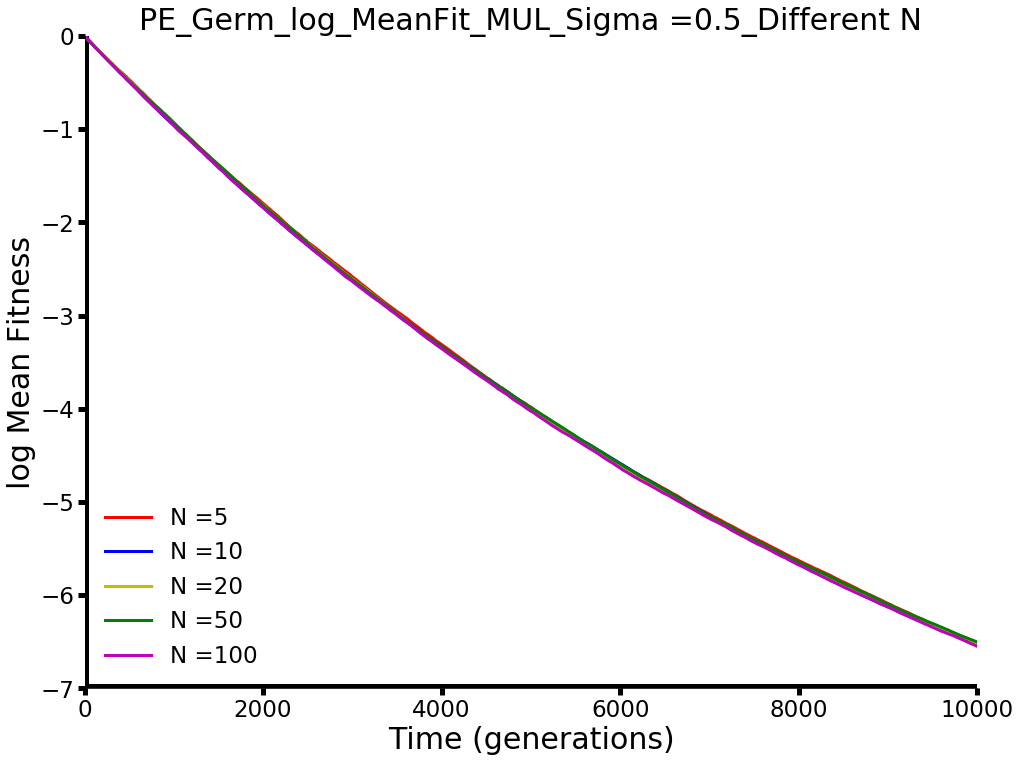

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

plt.figure(figsize=(16,12))

t = generation_list
a = g_s05_log_mfit[0]
b = g_s05_log_mfit[1]
c = g_s05_log_mfit[2]
d = g_s05_log_mfit[3]
e = g_s05_log_mfit[4]



plt.title('PE_Germ_log_MeanFit_MUL_Sigma =0.5_Different N', fontsize =30)
plt.xlabel('Time (generations)', fontsize =30)
plt.ylabel('log Mean Fitness', fontsize =30)
# plt.legend(['N =1', 'N =10', 'N =100', 'N =1000' ])
plt.rcParams.update({'font.size': 30})


# plt.show()
ax = plt.subplot(111)
ax.axhline(y=-7,linewidth=8, color ='black')       
ax.axvline(linewidth=8, color = 'black')        

plt.plot(t,a,'r', label = 'N =5', ls = 'solid',linewidth=3.0) # plotting t,a separately 
plt.plot(t,b,'b', label = 'N =10', ls= 'solid', linewidth=3.0) # plotting t,b separately 
plt.plot(t,c,'y', label = 'N =20', ls = 'solid', linewidth=3.0) # plotting t,c separately 
plt.plot(t,d,'g', label = 'N =50',ls = 'solid', linewidth=3.0)
plt.plot(t,e,'m', label = 'N =100', ls = 'solid', linewidth=3.0)
# plt.plot(t,f,'c', label = 'Sigma =10',ls= 'solid', linewidth=3.0)

plt.tick_params(axis='both', labelsize=23)


plt.xlim(0, 10001)


# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


ax.xaxis.set_tick_params(width=5, length =7)
ax.yaxis.set_tick_params(width=5, length =7)

# plt.legend(loc='upper right', frameon=False)
plt.legend(loc='lower left', frameon=False, prop={'size':23})

plt.ylim(-7,0)
# plt.savefig('1', dpi=300, bbox_inches='tight')

plt.show()